In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print("Setup complete!")

Setup complete!


In [13]:
# Load the dataset
import pandas as pd
splits = {'train': 'train.jsonl', 'test': 'test.jsonl'}

# We load the train split directly from Hugging Face into a pandas DataFrame.
# This gives us the text, numeric label, and label_text columns.
df = pd.read_json(
    "hf://datasets/SetFit/20_newsgroups/train.jsonl",
    lines=True
)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['label_text'].value_counts())

Dataset shape: (11314, 3)

Columns: ['text', 'label', 'label_text']

Label distribution:
label_text
rec.sport.hockey            600
soc.religion.christian      599
rec.motorcycles             598
rec.sport.baseball          597
sci.crypt                   595
sci.med                     594
rec.autos                   594
sci.space                   593
comp.windows.x              593
comp.os.ms-windows.misc     591
sci.electronics             591
comp.sys.ibm.pc.hardware    590
misc.forsale                585
comp.graphics               584
comp.sys.mac.hardware       578
talk.politics.mideast       564
talk.politics.guns          546
alt.atheism                 480
talk.politics.misc          465
talk.religion.misc          377
Name: count, dtype: int64


In [14]:
# TODO: Choose YOUR 3 categories (this affects all your analysis!)
# I put 3 example categories here.
# You should replace them with the 3 categories YOU want before submission.
my_categories = ["rec.autos", "sci.space", "talk.politics.guns"]

# We keep only the rows whose label_text matches one of the chosen categories.
# This makes the rest of the analysis focus only on these 3 topics.
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")
print(f"\nDistribution:")
print(df_filtered['label_text'].value_counts())

Selected categories: ['rec.autos', 'sci.space', 'talk.politics.guns']
Filtered dataset size: 1733

Distribution:
label_text
rec.autos             594
sci.space             593
talk.politics.guns    546
Name: count, dtype: int64


In [15]:
# Example preprocessing function
# TODO: Complete the function as needed
import re
import string

def preprocess_text(text):
    """Basic text preprocessing."""

    # Lowercase
    # We make everything lowercase so words like Car and car are treated the same.
    text = text.lower()

    # Remove emails
    # We remove email patterns because they are usually noise for topic analysis.
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove URLs
    # Links do not usually help identify the topic of the text.
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove numbers
    # Numbers are removed to focus on vocabulary rather than numeric values.
    text = re.sub(r'\d+', ' ', text)

    # Remove punctuation
    # Punctuation is removed so only words remain.
    text = re.sub(rf'[{re.escape(string.punctuation)}]', ' ', text)

    # Remove extra whitespace
    # After all replacements, many extra spaces may appear, so we normalize them.
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Test
sample = "Hello! Check this: http://example.com. Email me at test@email.com. Price: $100."
print(f"Original: {sample}")
print(f"Cleaned:  {preprocess_text(sample)}")

Original: Hello! Check this: http://example.com. Email me at test@email.com. Price: $100.
Cleaned:  hello check this email me at price


In [16]:
# TODO: Complete this improved preprocessing function
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt_tab', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text_advanced(text):
    """
    Advanced text preprocessing with stop words removal and lemmatization.

    Args:
        text (str): Input text
    Returns:
        str: Preprocessed text
    """
    # Step 1: Basic cleaning (lowercase, remove emails, URLs, numbers, punctuation)
    # We reuse the first preprocessing function so we do not repeat the same cleaning code.
    text = preprocess_text(text)

    # Step 2: Tokenize
    # Tokenization splits the cleaned text into individual words.
    tokens = word_tokenize(text)

    # Step 3: Remove stop words
    # Stop words like "the", "is", and "and" are frequent but usually not very informative.
    tokens = [token for token in tokens if token not in stop_words]

    # Step 4: Lemmatize
    # Lemmatization reduces words to their base form, e.g. "cars" -> "car".
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    # Step 5: Remove short words (< 3 chars)
    # Very short words often add little meaning, so we remove them.
    tokens = [token for token in tokens if len(token) >= 3]

    # Step 6: Join back to string
    # We join the cleaned tokens back into one string for vectorizers and word clouds.
    text = ' '.join(tokens)

    return text

# Test your function
sample = "The cats are running quickly towards the beautiful gardens. Email: test@mail.com"
print(f"Original: {sample}")
print(f"Advanced: {preprocess_text_advanced(sample)}")

Original: The cats are running quickly towards the beautiful gardens. Email: test@mail.com
Advanced: cat running quickly towards beautiful garden email


In [17]:
# Apply preprocessing to your filtered dataset
# We create a new column called text_clean so we keep both the original text and the cleaned version.
df_filtered['text_clean'] = df_filtered['text'].apply(preprocess_text_advanced)

# Show sample
print("Sample preprocessed document:")
print(df_filtered.iloc[0]['text_clean'][:300])

Sample preprocessed document:
wondering anyone could enlighten car saw day door sport car looked late early called bricklin door really small addition front bumper separate rest body know anyone tellme model name engine spec year production car made history whatever info funky looking car please mail


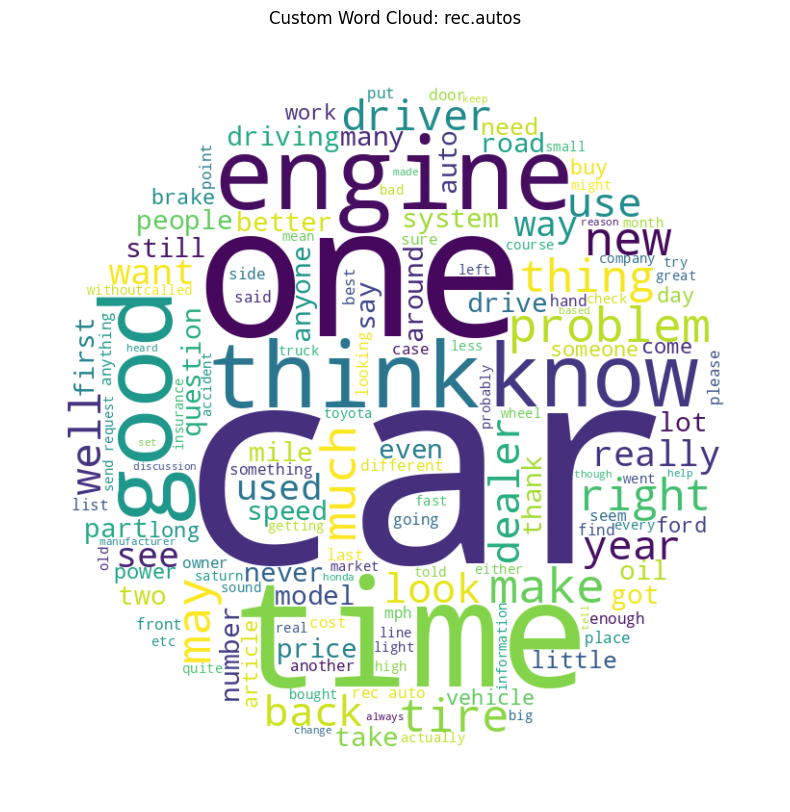

In [18]:
# TODO: Create a custom word cloud with a mask
# Choose ONE of your categories for this visualization

import numpy as np
from PIL import Image

# Create a simple circle mask
x, y = np.ogrid[:800, :800]
center_x, center_y = 400, 400
r = 350
circle_mask = (x - center_x)**2 + (y - center_y)**2 > r**2
circle_mask = 255 * circle_mask.astype(int)

# I used the first chosen category as an example.
# You can change this to any one of your 3 categories.
selected_category = my_categories[0]

# Get texts for selected category
# We combine all cleaned documents from that category into one big text.
texts = df_filtered[df_filtered['label_text'] == selected_category]['text_clean'].tolist()
text_combined = ' '.join(texts)

# Create word cloud with mask
# The mask controls the shape of the word cloud.
wordcloud_masked = WordCloud(
    width=800,
    height=800,
    background_color='white',
    mask=circle_mask,
    colormap='viridis',
    max_words=150,
    min_font_size=8
).generate(text_combined)

# Display
plt.figure(figsize=(10, 10))

# We display the generated word cloud as an image.
plt.imshow(wordcloud_masked, interpolation='bilinear')
plt.title(f'Custom Word Cloud: {selected_category}')
plt.axis('off')
plt.savefig('custom_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# TODO: Create a Bag of Words representation for your filtered dataset
# Use parameters: max_features=1000, min_df=5, max_df=0.95

# We create a CountVectorizer with the exact parameters requested.
# max_features limits vocabulary size, min_df removes rare words, and max_df removes too-common words.
bow_vectorizer_full = CountVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

# Fit and transform on your cleaned texts
# This converts each document into a vector of word counts.
bow_matrix_full = bow_vectorizer_full.fit_transform(df_filtered['text_clean'])

print(f"BoW Matrix shape: {bow_matrix_full.shape}")
print(f"Vocabulary size: {len(bow_vectorizer_full.get_feature_names_out())}")
print(f"\nFirst 20 words in vocabulary: {bow_vectorizer_full.get_feature_names_out()[:20]}")

BoW Matrix shape: (1733, 1000)
Vocabulary size: 1000

First 20 words in vocabulary: ['abiding' 'able' 'acceleration' 'access' 'accident' 'according' 'act'
 'action' 'activity' 'actually' 'add' 'addition' 'additional' 'address'
 'advantage' 'advertising' 'aerospace' 'age' 'agency' 'agent']


In [20]:
from sklearn.metrics.pairwise import cosine_similarity

# TODO: Compute cosine similarity between documents
# Then find the 2 most similar documents and the 2 most different documents

# Compute similarity matrix
# Cosine similarity compares document vectors and tells us how similar they are in vocabulary usage.
similarity_matrix = cosine_similarity(bow_matrix_full)

print(f"Similarity matrix shape: {similarity_matrix.shape}")

Similarity matrix shape: (1733, 1733)


In [21]:
# TODO: Find the 2 most similar documents (excluding self-similarity)
# Hint: Set diagonal to 0 or -1, then find argmax

# We copy the matrix so we do not modify the original similarity matrix.
sim_no_diag = similarity_matrix.copy()

# Self-similarity is always 1, so we replace the diagonal with -1 to ignore it.
np.fill_diagonal(sim_no_diag, -1)

# Find indices of most similar pair
# unravel_index converts the flat index from argmax back into row/column indices.
most_similar_idx = np.unravel_index(np.argmax(sim_no_diag), sim_no_diag.shape)
most_similar_score = sim_no_diag[most_similar_idx]

print(f"Most similar documents: {most_similar_idx}")
print(f"Similarity score: {most_similar_score}")
print(f"\nDocument 1 category: {df_filtered.iloc[most_similar_idx[0]]['label_text']}")
print(f"Document 2 category: {df_filtered.iloc[most_similar_idx[1]]['label_text']}")

Most similar documents: (np.int64(542), np.int64(966))
Similarity score: 1.0000000000000002

Document 1 category: sci.space
Document 2 category: sci.space


In [22]:
# TODO: Create TF-IDF representation for your dataset
# Use same parameters: max_features=1000, min_df=5, max_df=0.95

# TF-IDF keeps the same vectorization idea as BoW, but it gives less importance to very common words.
tfidf_vectorizer_full = TfidfVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

# Fit and transform the cleaned texts into TF-IDF vectors.
tfidf_matrix_full = tfidf_vectorizer_full.fit_transform(df_filtered['text_clean'])

print(f"TF-IDF Matrix shape: {tfidf_matrix_full.shape}")

TF-IDF Matrix shape: (1733, 1000)


In [23]:
# TODO: Find the top 10 most important words (highest TF-IDF) for each of your 3 categories

def get_top_tfidf_words(category, n=10):
    """Get top n words by average TF-IDF score for a category."""

    # 1. Get indices of documents in this category
    # We locate all rows belonging to the selected category.
    category_indices = df_filtered[df_filtered['label_text'] == category].index.tolist()

    # 2. Get their TF-IDF vectors
    # We select only the TF-IDF rows for this category.
    category_matrix = tfidf_matrix_full[category_indices]

    # 3. Compute mean TF-IDF for each word across these documents
    # This gives one average importance score per word for the whole category.
    mean_scores = np.asarray(category_matrix.mean(axis=0)).flatten()

    # 4. Return top n words
    # We sort the average scores in descending order and retrieve the top words.
    feature_names = tfidf_vectorizer_full.get_feature_names_out()
    top_indices = mean_scores.argsort()[::-1][:n]

    return [(feature_names[i], mean_scores[i]) for i in top_indices]

# Display top words for each category
for category in my_categories:
    top_words = get_top_tfidf_words(category, 10)
    print(f"\nTop TF-IDF words for '{category}':")
    print(top_words)


Top TF-IDF words for 'rec.autos':
[('car', np.float64(0.09803737857461828)), ('like', np.float64(0.03185986088846693)), ('would', np.float64(0.02980779636560454)), ('one', np.float64(0.027580984644181225)), ('engine', np.float64(0.02615669391039941)), ('get', np.float64(0.02565720385547186)), ('new', np.float64(0.025117420323977912)), ('good', np.float64(0.024793809673752838)), ('know', np.float64(0.022684968323762794)), ('also', np.float64(0.020144190956116394))]

Top TF-IDF words for 'sci.space':
[('space', np.float64(0.0685574679954602)), ('would', np.float64(0.036517157554770974)), ('one', np.float64(0.02735020993969287)), ('like', np.float64(0.027256392452842223)), ('nasa', np.float64(0.02670056128172514)), ('orbit', np.float64(0.024446473705363358)), ('launch', np.float64(0.02398237505816358)), ('moon', np.float64(0.022199638498564045)), ('year', np.float64(0.021393560152664557)), ('get', np.float64(0.021012830008193296))]

Top TF-IDF words for 'talk.politics.guns':
[('gun', np.

In [24]:
# TODO: Find the top 15 most common bigrams for each of your categories

bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    max_features=500,
    min_df=3
)

# For each category:
# 1. Get the texts
# 2. Fit the bigram vectorizer
# 3. Find most common bigrams

for category in my_categories:
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()

    # We fit the vectorizer only on the current category's texts.
    bigram_matrix = bigram_vectorizer.fit_transform(texts)

    # We sum all bigram counts across documents to get category-level frequencies.
    bigram_counts = np.asarray(bigram_matrix.sum(axis=0)).flatten()
    bigram_features = bigram_vectorizer.get_feature_names_out()

    # We sort bigrams by total count and keep the top 15.
    top_indices = bigram_counts.argsort()[::-1][:15]
    top_bigrams = [(bigram_features[i], bigram_counts[i]) for i in top_indices]

    print(f"\nTop bigrams for '{category}':")
    for bigram, count in top_bigrams[:15]:
        print(f"  {bigram}: {count}")


Top bigrams for 'rec.autos':
  rec auto: 41
  radar detector: 24
  would like: 21
  mailing list: 20
  year ago: 19
  new car: 19
  much better: 14
  sport car: 14
  oil change: 13
  look like: 13
  speed limit: 12
  car driver: 12
  sound like: 12
  year old: 11
  thing like: 11

Top bigrams for 'sci.space':
  space station: 69
  space shuttle: 66
  sci space: 58
  anonymous ftp: 38
  commercial space: 32
  remote sensing: 32
  gamma ray: 28
  launch vehicle: 27
  national space: 26
  sci astro: 25
  nasa ames: 24
  nasa gov: 24
  air force: 24
  space technology: 23
  pub space: 21

Top bigrams for 'talk.politics.guns':
  gun control: 116
  self defense: 74
  united state: 72
  second amendment: 56
  semi auto: 47
  anti gun: 34
  waiting period: 34
  gun owner: 33
  law enforcement: 32
  bear arm: 31
  assault weapon: 30
  law abiding: 30
  tear gas: 28
  gun law: 28
  keep bear: 27


In [26]:
# TODO: Build a bigram-based next word predictor

class SimpleNextWordPredictor:
    def __init__(self):
        self.bigram_counts = {}  # {word1: {word2: count, word3: count, ...}}
        self.unigram_counts = {}  # {word: count}

    def train(self, texts):
        """
        Train the model on a list of texts.

        Args:
            texts (list): List of preprocessed text strings
        """
        # 1. For each text, tokenize into words
        # 2. Count unigrams
        # 3. Count bigrams (word pairs)
        for text in texts:
            tokens = text.split()

            # Count each single word frequency.
            for token in tokens:
                self.unigram_counts[token] = self.unigram_counts.get(token, 0) + 1

            # Count each consecutive word pair.
            for i in range(len(tokens) - 1):
                word1 = tokens[i]
                word2 = tokens[i + 1]

                if word1 not in self.bigram_counts:
                    self.bigram_counts[word1] = {}

                self.bigram_counts[word1][word2] = self.bigram_counts[word1].get(word2, 0) + 1

    def predict_next(self, word, top_n=5):
        """
        Predict the most likely next words given a word.

        Args:
            word (str): The input word
            top_n (int): Number of predictions to return

        Returns:
            list: List of (next_word, probability) tuples
        """
        # 1. Look up the word in bigram_counts
        # If the word has never appeared as a first word in a bigram, return empty list.
        if word not in self.bigram_counts:
            return []

        next_words = self.bigram_counts[word]
        total_count = sum(next_words.values())

        # 2. Calculate probabilities: P(word2|word1) = count(word1, word2) / count(word1)
        predictions = [(next_word, count / total_count) for next_word, count in next_words.items()]

        # 3. Return top_n predictions sorted by probability
        predictions = sorted(predictions, key=lambda x: x[1], reverse=True)
        return predictions[:top_n]

# Train on your dataset
predictor = SimpleNextWordPredictor()
predictor.train(df_filtered['text_clean'].tolist())

In [27]:
# Test your predictor with words relevant to your categories
# TODO: Choose 5 test words that are relevant to YOUR chosen categories

# These are example words based on the example categories above.
# Replace them with words that match YOUR own chosen categories.
test_words = ["car", "engine", "space", "gun", "government"]

print("Next Word Predictions:")
print("=" * 40)

for word in test_words:
    predictions = predictor.predict_next(word.lower(), top_n=5)
    print(f"\n'{word}' ->")
    for next_word, prob in predictions:
        print(f"  {next_word}: {prob:.3f}")

Next Word Predictions:

'car' ->
  driver: 0.016
  like: 0.015
  would: 0.013
  driven: 0.009
  car: 0.009

'engine' ->
  size: 0.029
  compartment: 0.025
  noise: 0.020
  cutoff: 0.015
  used: 0.015

'space' ->
  station: 0.070
  shuttle: 0.067
  technology: 0.023
  program: 0.020
  news: 0.019

'gun' ->
  control: 0.127
  owner: 0.037
  law: 0.031
  ownership: 0.022
  would: 0.015

'government' ->
  agency: 0.030
  printing: 0.019
  people: 0.015
  industry: 0.011
  would: 0.011


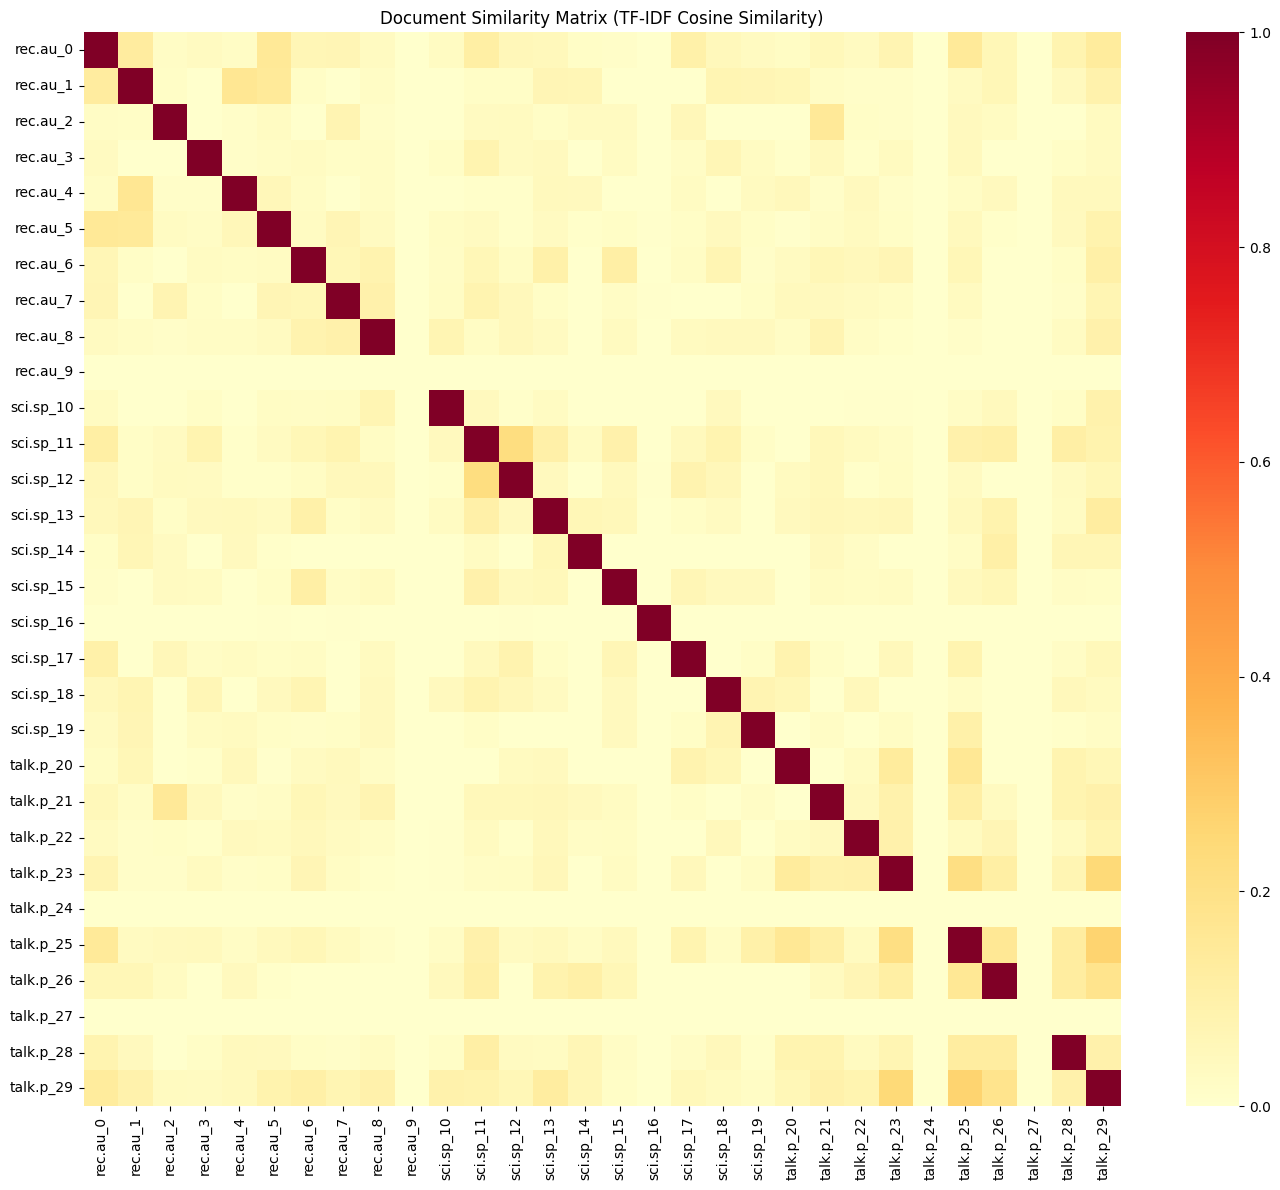

In [28]:
# TODO: Create a correlation/similarity heatmap between documents
# Sample 10 documents from each of your 3 categories (30 total)

import seaborn as sns

# Sample documents
sampled_dfs = []
for category in my_categories:
    # We randomly sample 10 documents from each category to make the heatmap readable.
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    sampled_dfs.append(cat_df)

df_sampled = pd.concat(sampled_dfs).reset_index(drop=True)

# Create TF-IDF for sampled documents
# TF-IDF is used here because it usually gives a better similarity signal than raw counts.
tfidf_sampled = TfidfVectorizer(max_features=500).fit_transform(df_sampled['text_clean'])

# Compute similarity matrix
# Cosine similarity shows how close each sampled document is to every other sampled document.
similarity_sampled = cosine_similarity(tfidf_sampled)

# Create labels for heatmap
labels = [f"{cat[:6]}_{i}" for cat, i in zip(df_sampled['label_text'], range(len(df_sampled)))]

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    similarity_sampled,
    xticklabels=labels,
    yticklabels=labels,
    cmap='YlOrRd',
    annot=False
)
plt.title('Document Similarity Matrix (TF-IDF Cosine Similarity)')
plt.tight_layout()
plt.savefig('document_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

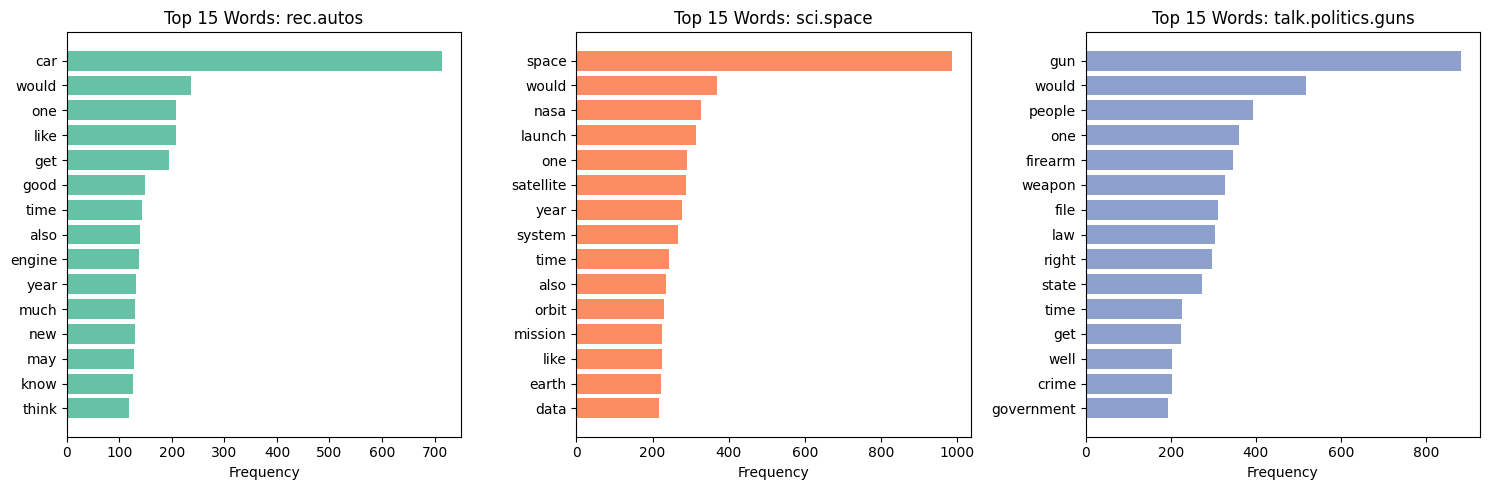

In [29]:
def get_top_words(texts, n=15):
    """Get the n most common words from a list of texts."""
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Get top words for each category
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    top_words = get_top_words(texts, 15)

    words, counts = zip(*top_words)
    axes[idx].barh(words, counts, color=plt.cm.Set2(idx))
    axes[idx].set_title(f'Top 15 Words: {category}')
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words_by_category.png', dpi=150, bbox_inches='tight')
plt.show()



*Category 1 (rec.autos):*
- Unique words: car, engine

*Category 2 (sci.space):*
- Unique words: space, orbit

*Category 3 (talk.politics.guns):*
- Unique words: gun, law

*Shared words and explanation:*
Some words like "people", "time", or "think" appear across multiple categories. These are general-purpose words that are used in many discussions regardless of the topic. They are not specific to one domain, which is why they show up in different categories.

*Topic guessing analysis:*
Yes, based only on the top words, it is possible to guess the topic of each category. For example, words like "car" and "engine" clearly indicate the autos category, while "space" and "orbit" point to space-related discussions. Similarly, words like "gun" and "law" suggest a political or legal discussion about firearms. This shows that frequent words can give a good indication of the main topic.

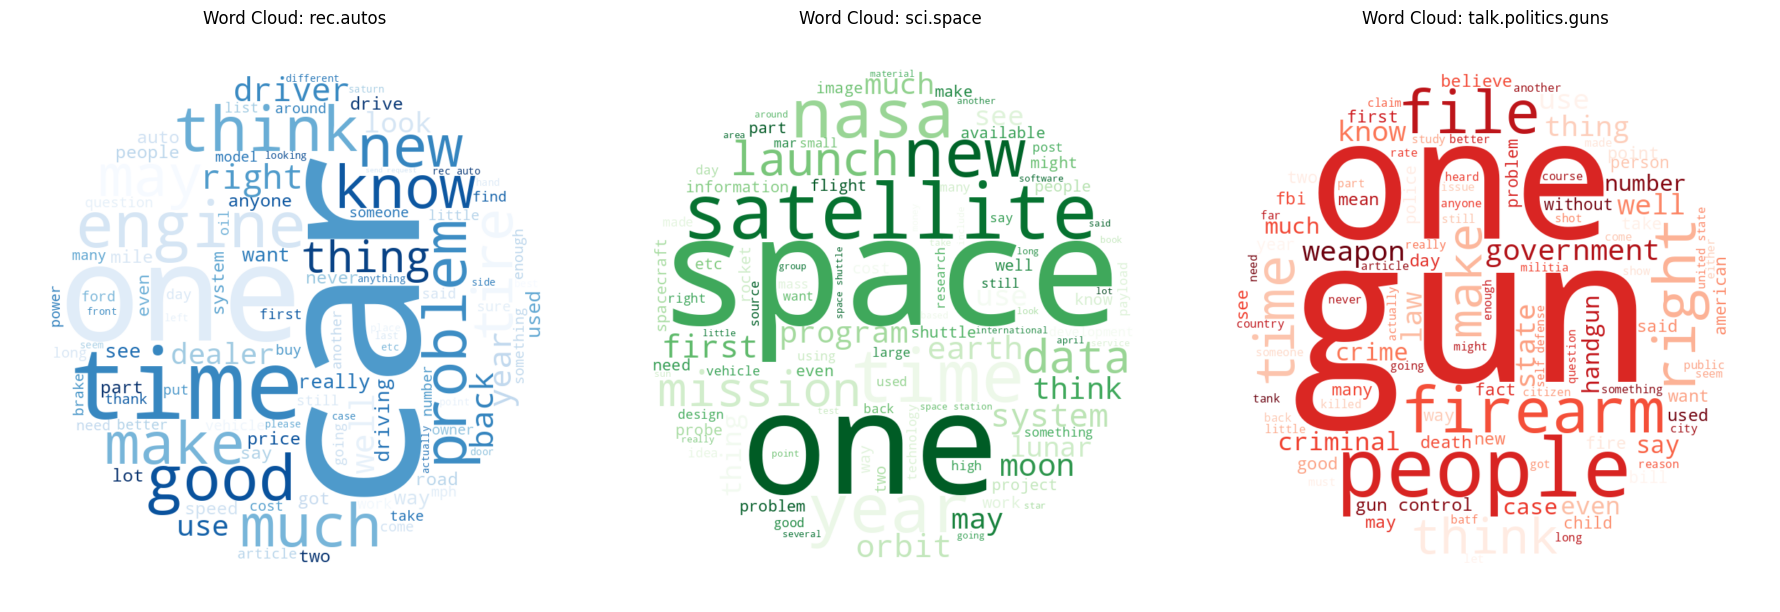

In [31]:
# Create word clouds for each category
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['Blues', 'Greens', 'Reds']

for idx, category in enumerate(my_categories):
    # Get texts for each category
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    text_combined = ' '.join(texts)

    # Create word cloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        mask=circle_mask,  # Apply mask for shape
        colormap=colors[idx],
        max_words=100,
        min_font_size=10
    ).generate(text_combined)

    # Display each word cloud
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Word Cloud: {category}')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordclouds_masked_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

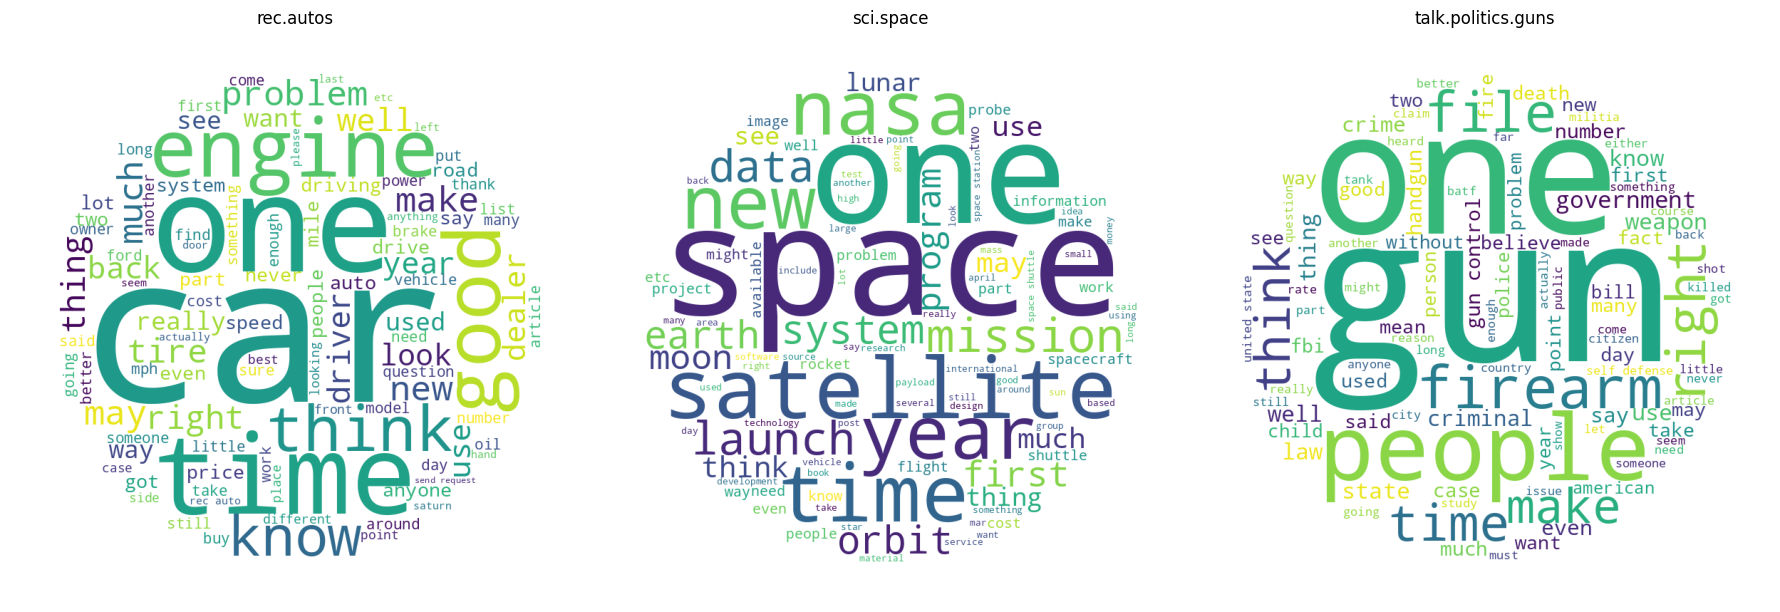

In [32]:
# Create 3 plots (one per category)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Loop through categories
for i, category in enumerate(my_categories):

    # Get cleaned text for this category
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean']
    text_combined = ' '.join(texts)

    # Create word cloud
    wc = WordCloud(
        background_color='white',
        mask=circle_mask,   # shape
        max_words=100
    ).generate(text_combined)

    # Display
    axes[i].imshow(wc)
    axes[i].set_title(category)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

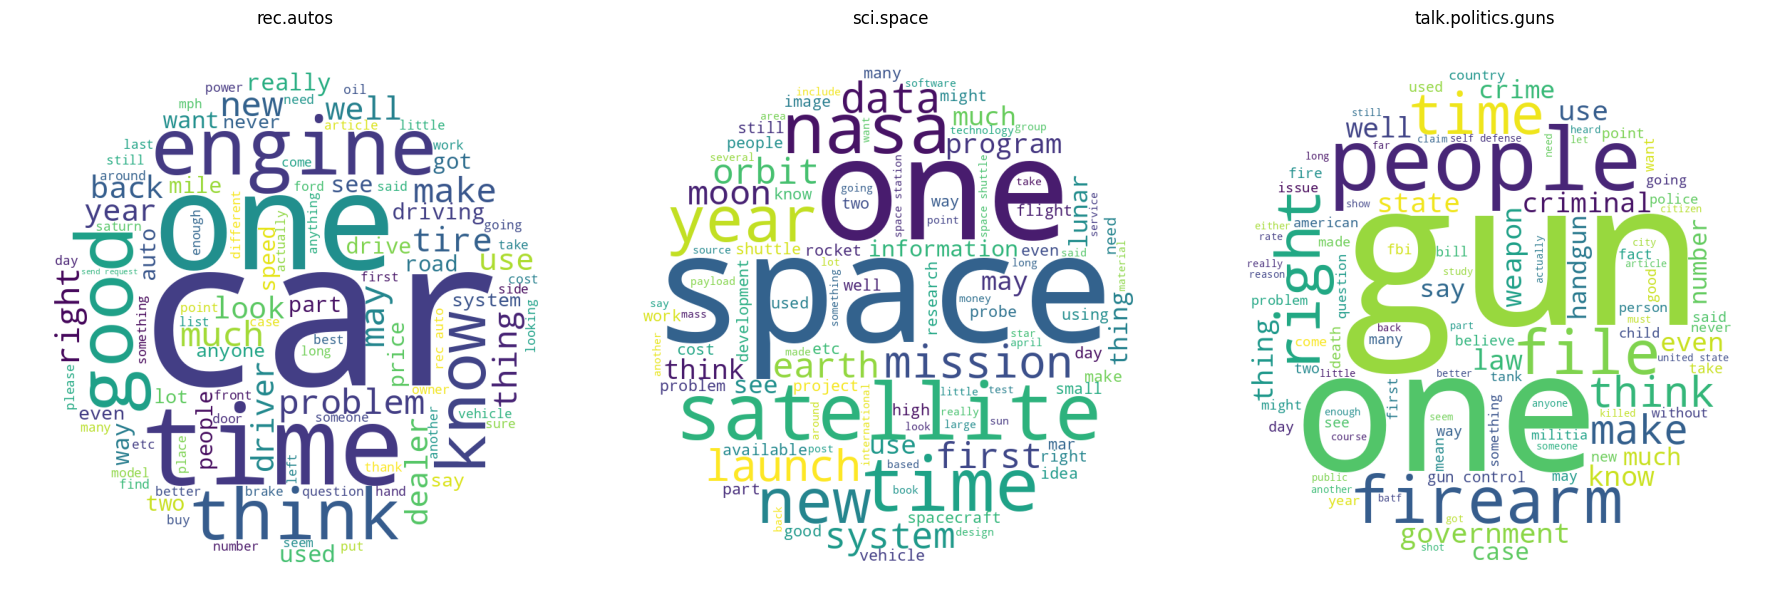

In [33]:
from nltk.corpus import stopwords

# Load stop words
stop_words = set(stopwords.words('english'))

# Create 3 plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, category in enumerate(my_categories):

    # Get cleaned text
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean']
    text_combined = ' '.join(texts)

    # Remove stop words
    filtered_words = [
        word for word in text_combined.split()
        if word not in stop_words
    ]
    text_filtered = ' '.join(filtered_words)

    # Create word cloud
    wc = WordCloud(
        background_color='white',
        mask=circle_mask,
        max_words=100
    ).generate(text_filtered)

    # Display
    axes[i].imshow(wc)
    axes[i].set_title(category)
    axes[i].axis('off')

plt.tight_layout()
plt.show()